# Walmart Weekly Sales Forecasting Using Machine Learning #

### This project aims to analyze Walmart sales data and build a machine learning model to Predict weekly sales using historical store and economic data . ###


### Objective: ###
### Predict weekly sales of Walmart stores using historical sales and economic factors such as temperature, fuel price, CPI, unemployment, and holiday information. ###


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gc
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('Walmart.csv')

In [3]:
df.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.shape

(6435, 8)

In [5]:
## The dataset contains weekly sales information for 45 Walmart stores from 2010 to 2012. ##

In [6]:
## Dataset Info 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 465.2 KB


In [7]:
## Statistical Summary
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [8]:
## Missing Values Check
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [9]:
## No missing values were found in the dataset. ##

## --- Store Analysis --- ##

In [10]:
## Top 5 Stores 
group_store = df.groupby('Store')
result = (group_store['Weekly_Sales'].mean()).sort_values(ascending = False)
result.head()                                                         

Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
Name: Weekly_Sales, dtype: float64

In [11]:
## Store 20 has highest average sales. ##

In [12]:
## Bottom 5 Stores 
group_store = df.groupby('Store')
result = (group_store['Weekly_Sales'].mean()).sort_values(ascending = False)
result.tail()            

Store
38    385731.653287
36    373511.992797
5     318011.810490
44    302748.866014
33    259861.692028
Name: Weekly_Sales, dtype: float64

In [13]:
## Store 38 has lowest average sales. ##

 ## -- Monthly Analysis -- ##

In [14]:
df['Date'] = pd.to_datetime(df['Date'],format = '%d-%m-%Y')

In [15]:
# Average Monthly Sales 
group_month = (df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean()).sort_values(ascending = False)
group_month.head()

Date
12    1.281864e+06
11    1.147266e+06
6     1.064325e+06
2     1.053200e+06
8     1.048017e+06
Name: Weekly_Sales, dtype: float64

In [16]:
 ## December records highest average sales. ##

In [17]:
group_month = (df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean()).sort_values(ascending = False)
group_month.tail()

Date
4     1.026762e+06
3     1.013309e+06
10    9.996321e+05
9     9.893353e+05
1     9.238846e+05
Name: Weekly_Sales, dtype: float64

In [18]:
 ## January records lowest average sales. ##

## -- Holiday Analysis -- ##

In [19]:
holiday_week = df['Holiday_Flag'] == 1
print(f"Holiday_week : {df.loc[holiday_week,'Weekly_Sales'].mean():.2f}")

Holiday_week : 1122887.89


In [20]:
non_holiday_week = df['Holiday_Flag'] == 0
print(f"Non_Holiday_week : {df.loc[non_holiday_week,'Weekly_Sales'].mean():.2f}")

Non_Holiday_week : 1041256.38


In [21]:
## Holiday weeks perform slightly better than non-holiday weeks. ##

 ## -- Sales Distribution -- ##

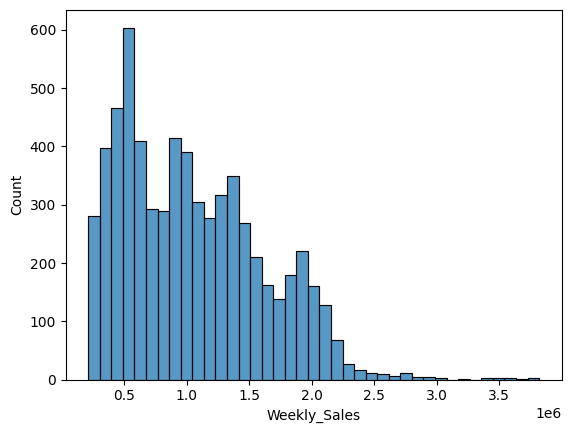

In [22]:
sns.histplot(x = 'Weekly_Sales',data= df)
plt.show()

In [23]:
 ## Weekly sales distribution is right-skewed. ##

## -- Correlation Analysis -- ## 

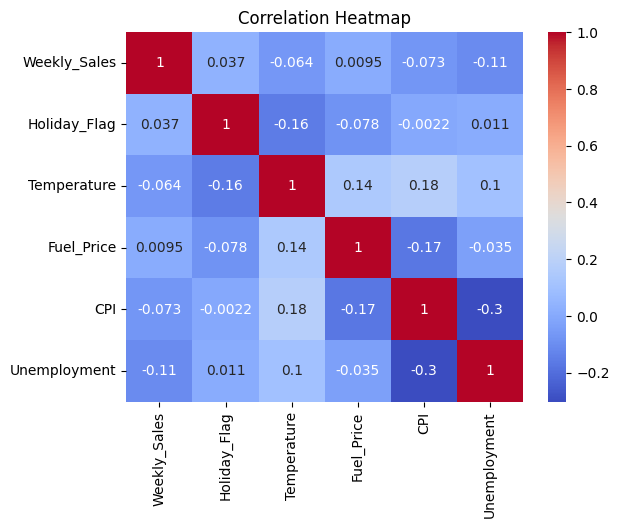

In [24]:
correlation_matrix = df[['Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment']].corr()
sns.heatmap(correlation_matrix,annot = True,cbar= True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [25]:
## Unemployment shows strongest negative correlation with weekly sales. ##
## Temperature shows very weak correlation. ##

## --- TIME SERIES FEATURE ENGINEERING --- ##

In [26]:
df = df.sort_values(by=['Store', 'Date'])

df['last_week_sales'] = df.groupby('Store')['Weekly_Sales'].shift(1)

df['rolling_mean_4'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(window=4).mean())

df.fillna(df['Weekly_Sales'].median(), inplace=True)

print("Time-series features added successfully!")
print(df[['Store', 'Date', 'Weekly_Sales', 'last_week_sales', 'rolling_mean_4']].head(10))

Time-series features added successfully!
   Store       Date  Weekly_Sales  last_week_sales  rolling_mean_4
0      1 2010-02-05    1643690.90        960746.04    9.607460e+05
1      1 2010-02-12    1641957.44       1643690.90    9.607460e+05
2      1 2010-02-19    1611968.17       1641957.44    9.607460e+05
3      1 2010-02-26    1409727.59       1611968.17    1.576836e+06
4      1 2010-03-05    1554806.68       1409727.59    1.554615e+06
5      1 2010-03-12    1439541.59       1554806.68    1.504011e+06
6      1 2010-03-19    1472515.79       1439541.59    1.469148e+06
7      1 2010-03-26    1404429.92       1472515.79    1.467823e+06
8      1 2010-04-02    1594968.28       1404429.92    1.477864e+06
9      1 2010-04-09    1545418.53       1594968.28    1.504333e+06


## -- Feature Engineering -- ##

In [27]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Week_Number'] = df['Date'].dt.isocalendar().week

In [28]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,last_week_sales,rolling_mean_4,Day,Month,Year,Week_Number
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,960746.04,960746.040,5,2,2010,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,1643690.90,960746.040,12,2,2010,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,1641957.44,960746.040,19,2,2010,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,1611968.17,1576836.025,26,2,2010,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,1409727.59,1554614.970,5,3,2010,9


In [29]:
df.drop('Date',axis = 1,inplace = True)

In [30]:
## Date information was decomposed into useful features for machine learning. ##

## -- Target AND Featuers -- ##

In [31]:
df['Store']= df['Store'].astype(object)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Store            6435 non-null   object 
 1   Weekly_Sales     6435 non-null   float64
 2   Holiday_Flag     6435 non-null   int64  
 3   Temperature      6435 non-null   float64
 4   Fuel_Price       6435 non-null   float64
 5   CPI              6435 non-null   float64
 6   Unemployment     6435 non-null   float64
 7   last_week_sales  6435 non-null   float64
 8   rolling_mean_4   6435 non-null   float64
 9   Day              6435 non-null   int32  
 10  Month            6435 non-null   int32  
 11  Year             6435 non-null   int32  
 12  Week_Number      6435 non-null   UInt32 
dtypes: UInt32(1), float64(7), int32(3), int64(1), object(1)
memory usage: 559.4+ KB


In [33]:
Y = df['Weekly_Sales']
X = df.drop(columns = 'Weekly_Sales')

## -- Numerical Vs Categorical Columns -- ##

In [34]:
num_X = X.select_dtypes(include = 'number').columns.tolist()
cat_X = X.select_dtypes(exclude = 'number').columns.tolist()

## -- Preprocessig Pipeline -- ##

In [35]:
number_transformation = Pipeline(steps = [("Imputer",SimpleImputer(strategy = "median")),
                                          ("Scaling",StandardScaler())])

In [36]:
category_transformation = Pipeline(steps = [("Imputer",SimpleImputer(strategy = "most_frequent")),
                                            ("OneHotEncoding",OneHotEncoder(handle_unknown = "ignore"))])

In [37]:
preprocessor = ColumnTransformer(transformers = [("num",number_transformation,num_X),
                                                ("cat",category_transformation,cat_X)],
                                                 remainder = "drop")

In [38]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## -- Trian Test Spilt -- ##

In [39]:
train_df = df[df['Year'] != 2012]
test_df = df[df['Year'] == 2012]

X_train = train_df.drop(columns=['Weekly_Sales'])
Y_train = train_df['Weekly_Sales']

X_test = test_df.drop(columns=['Weekly_Sales'])
Y_test = test_df['Weekly_Sales']


In [40]:
X_test

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,last_week_sales,rolling_mean_4,Day,Month,Year,Week_Number
100,1,0,49.01,3.157,219.714258,7.348,1497462.72,1.799800e+06,6,1,2012,1
101,1,0,48.53,3.261,219.892526,7.348,1550369.92,1.694406e+06,13,1,2012,2
102,1,0,54.11,3.268,219.985689,7.348,1459601.17,1.475457e+06,20,1,2012,3
103,1,0,54.26,3.290,220.078852,7.348,1394393.84,1.430923e+06,27,1,2012,4
104,1,0,56.55,3.360,220.172015,7.348,1319325.59,1.452415e+06,3,2,2012,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,0,64.88,3.997,192.013558,8.684,723086.20,7.262528e+05,28,9,2012,39
6431,45,0,64.89,3.985,192.170412,8.667,713173.95,7.179884e+05,5,10,2012,40
6432,45,0,54.47,4.000,192.327265,8.667,733455.07,7.260449e+05,12,10,2012,41
6433,45,0,56.47,3.969,192.330854,8.667,734464.36,7.248047e+05,19,10,2012,42


### 2010 and 2011 data used for training. ###
### 2012 data used for testing. ###

In [41]:
 ## Future sales should be predicted using historical data. ##

## -- Training Linear Regression Model -- ##

In [42]:
model_1 = LinearRegression()
final_process = Pipeline(steps = [("Preprocessor",preprocessor),
                                 ("Model",model_1)])

In [43]:
final_process

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [44]:
final_process.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Store','Holiday_Flag','Temperature',...,'Month','Year','Week_Number']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [45]:
## Linear Regression was used because Weekly Sales is a continuous numerical variable. ##

## -- Evaluation With MSE,RMSE,MAE,R2 --  ##

In [46]:
predictions = final_process.predict(X_test)

In [47]:
print(f"Linear Regression : {r2_score(Y_test,predictions)}")

Linear Regression : 0.9581616770335877


In [48]:
print(f"Linear Regression : {mean_squared_error(Y_test,predictions)}")

Linear Regression : 12043081606.96792


In [49]:
print(f"Linear Regression : {mean_absolute_error(Y_test,predictions)}")

Linear Regression : 85358.50699377994


In [50]:
print(f"Linear Regression : {root_mean_squared_error(Y_test,predictions)}")

Linear Regression : 109740.97505930919


In [51]:
## The model explains approximately 94.4% of variation in weekly sales. ##

## -- Actual vs Predicted Analysis -- ##

In [52]:
comparision  = pd.DataFrame()

In [53]:
difference = Y_test - predictions 
comparision['Actual'] = Y_test
comparision['Predicted'] = predictions
comparision['Difference'] = difference
comparision.head(5)

,Actual,Predicted,Difference
100,1550369.92,1.634760e+06,-84389.962371
101,1459601.17,1.573534e+06,-113932.555670
102,1394393.84,1.436933e+06,-42538.965442
103,1319325.59,1.410530e+06,-91204.400007
104,1636339.65,1.470678e+06,165661.507772


In [54]:
## Predicted values closely follow actual values, indicating good model performance. ##

 # Using RandomForestRegressor #

In [55]:
# n_estimators=100 means we use 100 decision trees to vote on the result
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

final_process = Pipeline(steps = [
    ("Preprocessor", preprocessor),
    ("Model", model)
])

final_process.fit(X_train, Y_train)

predictions = final_process.predict(X_test)
print(f"Random Forest R2 Score: {r2_score(Y_test, predictions)}")

Random Forest R2 Score: 0.9847807377437217


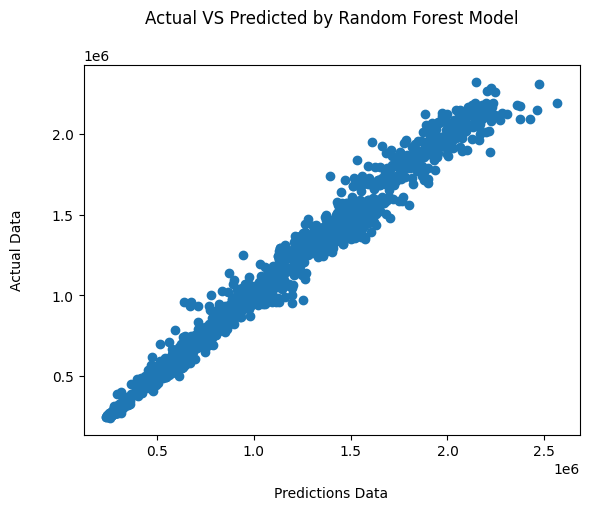

In [56]:
plt.scatter(Y_test,predictions)
plt.title("Actual VS Predicted by Random Forest Model",pad=30)
plt.xlabel("Predictions Data",labelpad=20)
plt.ylabel("Actual Data",labelpad=20)
plt.show()

## -- Feature Importance -- ##

In [57]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 features
importance_df.head(10)

,Feature,Importance
5,num__last_week_sales,0.685880
6,num__rolling_mean_4,0.270273
10,num__Week_Number,0.023049
7,num__Day,0.006879
24,cat__Store_14,0.002053
30,cat__Store_20,0.001386
0,num__Holiday_Flag,0.001385
8,num__Month,0.001089
14,cat__Store_4,0.000865
1,num__Temperature,0.000855


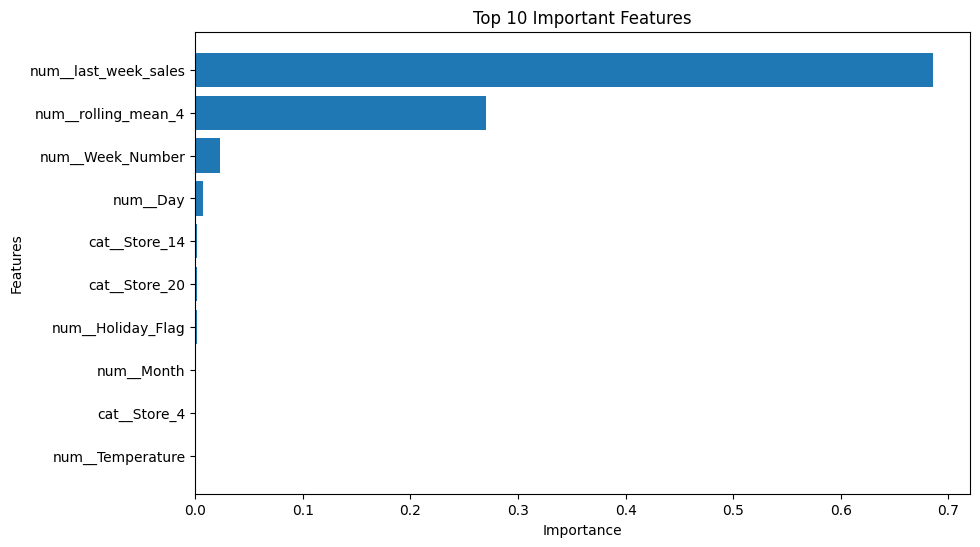

In [58]:
top10 = importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [59]:
 ## Feature importance analysis shows that historical sales features such as Last_Week_Sales and Rolling_Mean_4 contribute most to the model's predictions.##
 ## Economic indicators such as CPI and Unemployment have moderate influence, while temperature and fuel price have relatively lower impact. ##

## -- Model Comparison -- ##

In [60]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "R2":[0.944,0.980]
})

comparison

,Model,R2
0,Linear Regression,0.944
1,Random Forest,0.980


In [61]:
# Random Forest achieved a higher R² score than Linear Regression, indicating its ability to capture complex non-linear relationships in the dataset. #

## -- Key Findings -- ##

• Store 20 recorded the highest average weekly sales, while Store 38 recorded the lowest average weekly sales.

• December generated the highest average sales, whereas January recorded the lowest average sales.

• Holiday weeks generally performed better than non-holiday weeks, indicating the impact of seasonal shopping behavior.

• Weekly sales distribution was right-skewed, showing the presence of several high-sales weeks.

• Unemployment exhibited the strongest negative relationship with weekly sales among the economic indicators.

• Temperature and Fuel Price showed relatively weak relationships with weekly sales.

• Historical sales features such as Last_Week_Sales and Rolling_Mean_4 were among the most influential predictors in the Random Forest model.

• Feature importance analysis revealed that previous sales patterns contribute more to prediction accuracy than external economic factors.

• Random Forest outperformed Linear Regression by capturing complex and non-linear relationships within the data.

• The final Random Forest model achieved an R² score of approximately 0.98, indicating excellent predictive performance.

# Conclusion #

## This project successfully analyzed Walmart weekly sales data and developed machine learning models to forecast future sales patterns. The analysis included data preprocessing, exploratory data analysis, feature engineering, model training, and model evaluation. ##

## Several important business insights were identified during the analysis. Store 20 consistently achieved the highest average sales, while December emerged as the strongest sales month. Holiday periods generally resulted in increased sales activity, and unemployment showed a noticeable negative impact on weekly sales performance. ##

## To improve prediction accuracy, additional time-based and historical sales features such as Last_Week_Sales and Rolling_Mean_4 were engineered. These features proved to be highly influential in forecasting future sales. ##

## Both Linear Regression and Random Forest models were evaluated. While Linear Regression produced strong results, Random Forest delivered superior performance by effectively capturing non-linear relationships within the data. The final Random Forest model achieved an R² score of approximately 0.98, demonstrating excellent predictive capability. ##

## Finally, the trained model was deployed using Streamlit, allowing users to interact with the forecasting system through a user-friendly web application. Overall, this project demonstrates the complete machine learning workflow, from data analysis and feature engineering to model deployment and real-world sales forecasting. ##

In [62]:
import joblib
joblib.dump(final_process, 'walmart_model_rf.pkl')

['walmart_model_rf.pkl']